# mBRSET MedSigLIP embeddings

This notebook demonstrates how to use the clean mBRSET dataset with MedSigLIP. It reads the metadata file, selects example retinal fundus images from the dataset, extracts image and text embeddings, compares them with simple ophthalmology prompts, and visualizes the embeddings with PCA.

----

Este notebook muestra cómo usar el dataset limpio mBRSET con MedSigLIP. Lee el archivo de metadata, selecciona ejemplos de imágenes de fondo de ojo desde el dataset, extrae embeddings de imagen y texto, los compara con prompts simples de oftalmología y visualiza los embeddings con PCA.


In [1]:
from pathlib import Path
import os

from dotenv import load_dotenv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.decomposition import PCA
import torch
from transformers import AutoModel, AutoProcessor

load_dotenv()
HF_TOKEN = os.getenv("HF_TOKEN")
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

MODEL_ID = "google/medsiglip-448"
processor = AutoProcessor.from_pretrained(MODEL_ID, token=HF_TOKEN)
model = AutoModel.from_pretrained(MODEL_ID, token=HF_TOKEN).to(device)
model.eval()


device: cpu


The image processor of type `SiglipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/888 [00:00<?, ?it/s]

SiglipModel(
  (text_model): SiglipTextTransformer(
    (embeddings): SiglipTextEmbeddings(
      (token_embedding): Embedding(32000, 1152)
      (position_embedding): Embedding(64, 1152)
    )
    (encoder): SiglipEncoder(
      (layers): ModuleList(
        (0-26): 27 x SiglipEncoderLayer(
          (layer_norm1): LayerNorm((1152,), eps=1e-06, elementwise_affine=True)
          (self_attn): SiglipAttention(
            (k_proj): Linear(in_features=1152, out_features=1152, bias=True)
            (v_proj): Linear(in_features=1152, out_features=1152, bias=True)
            (q_proj): Linear(in_features=1152, out_features=1152, bias=True)
            (out_proj): Linear(in_features=1152, out_features=1152, bias=True)
          )
          (layer_norm2): LayerNorm((1152,), eps=1e-06, elementwise_affine=True)
          (mlp): SiglipMLP(
            (activation_fn): GELUTanh()
            (fc1): Linear(in_features=1152, out_features=4304, bias=True)
            (fc2): Linear(in_features=4304,

In [2]:
# Reemplazar con tu ruta al dataset
# DATASET_DIR = Path("PATH-TO-DATASET/mBRSET")
DATASET_DIR = Path(os.environ["SCRATCH"]) / "datasets" / "datatondatasets" / "mBRSET"

metadata = pd.read_csv(DATASET_DIR / "metadata.csv")
print(metadata.shape)
metadata.head()


(2399, 26)


,image,split,patient,age,sex,dm_time,insulin,insulin_time,oraltreatment_dm,systemic_hypertension,...,acute_myocardial_infarction,nephropathy,neuropathy,diabetic_foot,laterality,final_artifacts,final_quality,final_icdr,final_edema,increased_cdr
0,1.1.jpg,train,1,58,1,15.0,1.0,NaN,1.0,1.0,...,1.0,1.0,0.0,0.0,right,yes,yes,4,no,no
1,1.2.jpg,train,1,58,1,15.0,1.0,NaN,1.0,1.0,...,1.0,1.0,0.0,0.0,right,yes,yes,4,no,no
2,1.3.jpg,train,1,58,1,15.0,1.0,NaN,1.0,1.0,...,1.0,1.0,0.0,0.0,left,yes,yes,4,no,no
3,1.4.jpg,train,1,58,1,15.0,1.0,NaN,1.0,1.0,...,1.0,1.0,0.0,0.0,left,yes,yes,4,no,no
4,2.1.jpg,train,2,49,1,5.0,0.0,NaN,1.0,1.0,...,0.0,0.0,0.0,0.0,right,yes,yes,0,no,no


In [3]:
def load_rgb(path):
    return Image.open(path).convert("RGB")


def run_medsiglip(images, texts):
    inputs = processor(
        text=texts,
        images=images,
        padding="max_length",
        return_tensors="pt",
    ).to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    probs = torch.softmax(outputs.logits_per_image, dim=1).detach().cpu().numpy()
    image_embeds = outputs.image_embeds.detach().cpu().numpy()
    text_embeds = outputs.text_embeds.detach().cpu().numpy()
    return probs, image_embeds, text_embeds


def show_predictions(images, texts, probs):
    for image_index, image in enumerate(images):
        display(image)
        for text, score in zip(texts, probs[image_index]):
            print(f"{score:.2%} - {text}")
        print()


def plot_embedding_pca(image_embeds, text_embeds, image_labels, text_labels, title):
    vectors = np.vstack([image_embeds, text_embeds])
    coords = PCA(n_components=2, random_state=0).fit_transform(vectors)
    n_images = len(image_embeds)

    plt.figure(figsize=(7, 5))
    plt.scatter(coords[:n_images, 0], coords[:n_images, 1], label="images", s=90)
    plt.scatter(coords[n_images:, 0], coords[n_images:, 1], label="texts", marker="x", s=90)

    for label, (x, y) in zip(image_labels, coords[:n_images]):
        plt.text(x, y, label, fontsize=9)
    for label, (x, y) in zip(text_labels, coords[n_images:]):
        plt.text(x, y, label, fontsize=9)

    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [4]:
sample = metadata.sample(min(2, len(metadata)), random_state=4).reset_index(drop=True)
images = [load_rgb(DATASET_DIR / "images" / row.image) for row in sample.itertuples()]
image_labels = [f"image {i}" for i in range(len(images))]

texts = [
    "a retinal fundus photograph with no diabetic retinopathy",
    "a retinal fundus photograph with diabetic retinopathy",
    "a retinal fundus photograph with macular edema",
    "a retinal fundus photograph with increased cup-to-disc ratio",
]

sample[["image", "final_icdr", "final_edema", "increased_cdr", "final_quality"]].head()


,image,final_icdr,final_edema,increased_cdr,final_quality
0,180.3.jpg,2,yes,yes,yes
1,354.1.jpg,0,no,no,yes


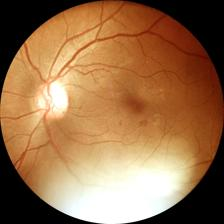

25.72% - a retinal fundus photograph with no diabetic retinopathy
26.95% - a retinal fundus photograph with diabetic retinopathy
22.06% - a retinal fundus photograph with macular edema
25.27% - a retinal fundus photograph with increased cup-to-disc ratio



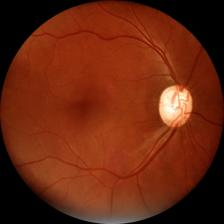

24.14% - a retinal fundus photograph with no diabetic retinopathy
18.30% - a retinal fundus photograph with diabetic retinopathy
23.26% - a retinal fundus photograph with macular edema
34.30% - a retinal fundus photograph with increased cup-to-disc ratio

image embeddings: (2, 1152)
text embeddings: (4, 1152)


In [5]:
probs, image_embeds, text_embeds = run_medsiglip(images, texts)
show_predictions(images, texts, probs)
print("image embeddings:", image_embeds.shape)
print("text embeddings:", text_embeds.shape)


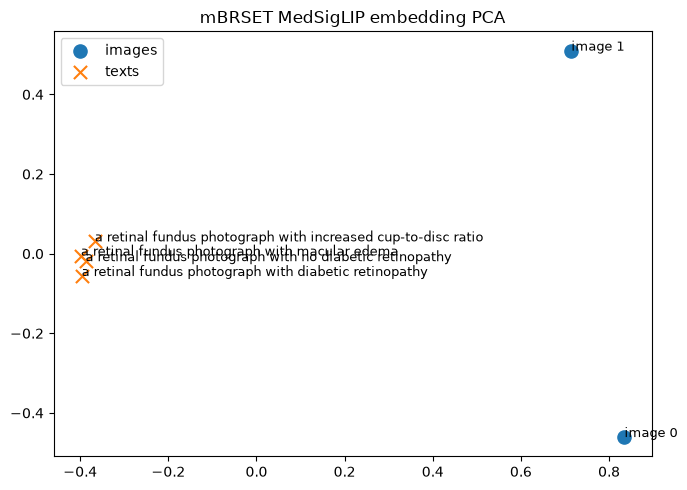

In [6]:
plot_embedding_pca(
    image_embeds,
    text_embeds,
    image_labels=image_labels,
    text_labels=texts,
    title="mBRSET MedSigLIP embedding PCA",
)
